In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Cell 2 - Load Dataset
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
# Cell 3 - Inspect Dataset

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes:

In [ ]:
# Cell 4 - Clean Column Names

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
)

print("Cleaned Column Names:")
print(df.columns.tolist())

Cleaned Column Names:
['udi', 'product_id', 'type', 'air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf']


In [ ]:
# Cell 5 - Prepare Target Variable

target_column = "machine_failure"

print("Target Distribution:")
print(df[target_column].value_counts())

print("\nTarget Percentage:")
print(df[target_column].value_counts(normalize=True) * 100)

print("\n0 = No Failure")
print("1 = Failure")

Target Distribution:
machine_failure
0    9661
1     339
Name: count, dtype: int64

Target Percentage:
machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64

0 = No Failure
1 = Failure


In [ ]:
# Cell 6 - Remove Unnecessary Columns

# Remove duplicate rows
df = df.drop_duplicates()

# Remove identifier columns
columns_to_remove = ["udi", "product_id"]

for column in columns_to_remove:
    if column in df.columns:
        df = df.drop(columns=column)

print("Dataset shape after cleaning:", df.shape)

print("\nRemaining columns:")
print(df.columns.tolist())

Dataset shape after cleaning: (10000, 12)

Remaining columns:
['type', 'air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf']


In [ ]:
# Cell 7 - Separate Features and Target

X = df.drop(columns=[target_column])
y = df[target_column]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target_column)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['type', 'air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'twf', 'hdf', 'pwf', 'osf', 'rnf']

Target:
machine_failure

X shape: (10000, 11)
y shape: (10000,)


In [ ]:
# Cell 8 - Identify Feature Types

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'twf', 'hdf', 'pwf', 'osf', 'rnf']

Categorical Features:
['type']


In [ ]:
# Cell 9 - Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

Training data: (8000, 11)
Testing data: (2000, 11)

Training target distribution:
machine_failure
0    7729
1     271
Name: count, dtype: int64


In [ ]:
# Cell 10 - Preprocessing and Logistic Regression

# Numerical preprocessing
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

# Logistic Regression baseline
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Complete machine learning pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", logistic_model)
    ]
)

print("Logistic Regression baseline model is ready!")

Logistic Regression baseline model is ready!


In [ ]:
# Cell 11 - Train Model and Make Predictions

print("Training the model...")

model.fit(X_train, y_train)

print("Model trained successfully!")

# Predict failure class
y_pred = model.predict(X_test)

# Predict probability of failure
y_probability = model.predict_proba(X_test)[:, 1]

print("\nPredictions completed!")

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 failure probabilities:")
print(np.round(y_probability[:10], 3))

Training the model...
Model trained successfully!

Predictions completed!

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 failure probabilities:
[0.02  0.028 0.017 0.013 0.06  0.051 0.036 0.044 0.008 0.002]


       BASELINE MODEL RESULTS
Accuracy  : 0.9990
Precision : 1.0000
Recall    : 0.9706
F1-Score  : 0.9851

Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1932
     Failure       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix:
[[1932    0]
 [   2   66]]


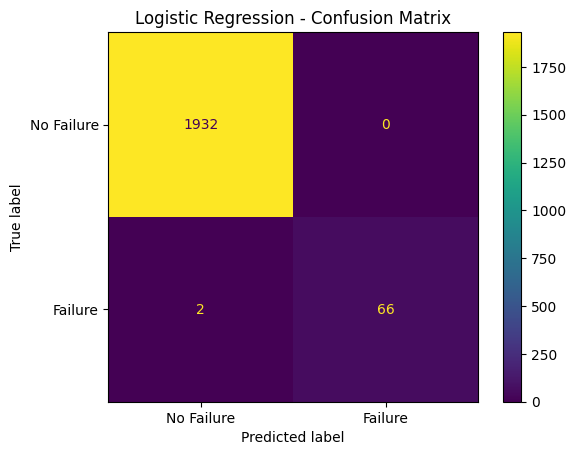


Sample Risk Predictions:


,actual_failure,predicted_failure,failure_probability,risk_level
2997,0,0,0.020463,Low Risk
4871,0,0,0.027839,Low Risk
3858,0,0,0.016529,Low Risk
951,0,0,0.012846,Low Risk
6463,0,0,0.059879,Low Risk
3264,0,0,0.051163,Low Risk
4508,0,0,0.036150,Low Risk
2100,0,0,0.043798,Low Risk
7885,0,0,0.007672,Low Risk
2421,0,0,0.002148,Low Risk


In [ ]:
# Cell 12 - Model Evaluation and Risk Classification

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Display results
print("======================================")
print("       BASELINE MODEL RESULTS")
print("======================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# Classification report
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Failure", "Failure"],
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# --------------------------------------
# Risk Classification
# --------------------------------------

def classify_risk(probability):

    if probability >= 0.70:
        return "High Risk"

    elif probability >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"


# Create results table
results = X_test.copy()

results["actual_failure"] = y_test.values
results["predicted_failure"] = y_pred
results["failure_probability"] = y_probability

results["risk_level"] = results["failure_probability"].apply(
    classify_risk
)

print("\nSample Risk Predictions:")

display(
    results[
        [
            "actual_failure",
            "predicted_failure",
            "failure_probability",
            "risk_level"
        ]
    ].head(10)
)